# BioJEPA v0.7 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_7 import BioJepa, BioJepaConfig
from dataloader_v0_7 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v0_7 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v0_7 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/jepa/v0_7').expanduser()
ref_root = Path('~/data/jepa/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cpu


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=2, #6
    heads=2, #4
    embed_dim= 8, #256
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=25,
    std_coeff=25,
    cov_coeff=1,
    pert_latent_dim=128,
    pert_mode_dim=64,
)

# Encoder training: WSD schedule with context L2 and EMA annealing in phase 2
encoder_cfg = EncoderTrainingConfig(
    n_steps = 1000,
    #epochs=1, 
    lr=1e-4, batch_size=64, phase2_start_pct=0.8, context_coeff=2.0, context_ramp_pct=0.2, ema_final_momentum=1.0,
)

# Composer training: InfoNCE loss with modality-balanced sampling (v0.7 HPO v3 winner)
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=2.5e-4, batch_size=64, weight_decay=0.011, temperature=0.0015, chemical_fraction=0.1,
)

# AC training: mask annealing in final 20%
ac_cfg = ACTrainingConfig(
    n_steps = 1000,
    #epochs=1, 
    predictor_lr=1e-4, batch_size=32, mask_anneal_pct=0.2, mask_anneal_floor=0.0,
)

decoder_cfg = DecoderConfig(epochs=1, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 84,082
ACpredictor: 85,824
PerturbationComposer: 510,400


### Load pretraining model from checkpoint (for resuming)

In [5]:
# checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_7_ac_final.pt'
# with torch.serialization.safe_globals([BioJepaConfig]):
#     checkpoint = torch.load(checkpoint_path, map_location=device)

# keys = model.load_state_dict(checkpoint['model'])
# keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Encoder Training

In [ ]:
# decompress_npz(data_cfg.data_root / 'encoder_t')

In [6]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device )
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device)

found 1175 shards for split train
shard balancing (threshold=133, 20% of max=664):
  adamson: 23 -> 138 shards (x6)
  k562e_raw: 98 -> 196 shards (x2)
  k562gw: 664 shards
  norman: 39 -> 156 shards (x4)
  rep1e: 83 -> 166 shards (x2)
  sciplex: 268 shards
found 70 shards for split val


In [6]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

Encoder training: 4065280 samples, 63520 steps/epoch, 1000 total steps
WSD schedule: warmup=50 steps, phase2 starts at step 800
Context L2: target=2.0, ramp starts at step 800
EMA annealing: 0.995 -> 1.0 during phase 2
Step 0 | val loss: 74.7014
Step 0 | Loss: 74.12534 | LR: 2.00e-06 | Phase: 1
Step 100 | Loss: 58.85537 | LR: 1.00e-04 | Phase: 1
Step 200 | Loss: 37.85822 | LR: 1.00e-04 | Phase: 1
Step 300 | Loss: 27.65254 | LR: 1.00e-04 | Phase: 1
Step 400 | Loss: 23.82232 | LR: 1.00e-04 | Phase: 1
Step 500 | val loss: 16.2770
Step 500 | Loss: 16.20064 | LR: 1.00e-04 | Phase: 1
Step 600 | Loss: 15.81695 | LR: 1.00e-04 | Phase: 1
Step 700 | Loss: 19.41695 | LR: 1.00e-04 | Phase: 1
Step 800 | Loss: 19.30061 | LR: 9.95e-05 | Phase: 2
Step 900 | Loss: 21.62449 | LR: 4.95e-05 | Phase: 2
Step 999 | val loss: 20.9004


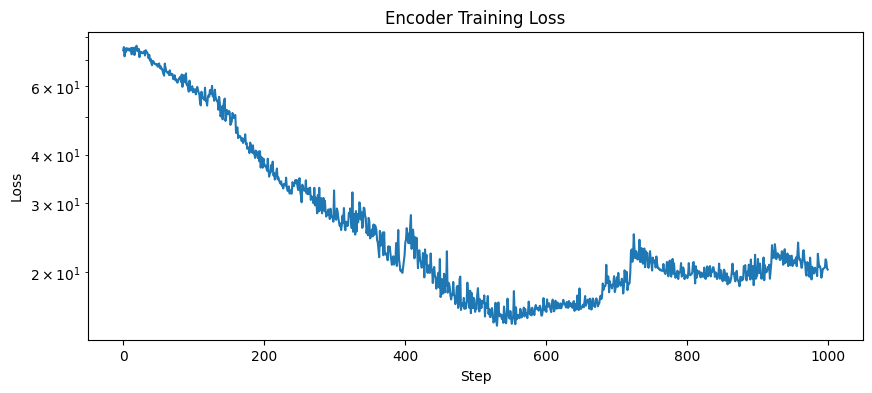

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [8]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Encoder Training Evals

In [7]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

Using cpu
found 135 shards for split test


batch_invariance: Extracting embeddings: 100%|█████████████████| 5400/5400 [57:50<00:00,  1.56it/s]


Training classifiers...
batch_invariance: Batch=0.0035 (1.5x), Pert=0.0110 (12.2x)
batch_invariance summary: global_ratio=3.128, within_dataset_macro_ratio=0.906
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
gene_embedding_pathways: KEGG ratio=0.9976
essential_gene_prediction: Pearson=0.0557, AUROC=0.5266
found 135 shards for split test


cell_type_probing: Extracting embeddings: 100%|████████████████| 5400/5400 [27:58<00:00,  3.22it/s]


Training cell type classifier...
cell_type_probing: Accuracy=0.6240 (2.5x chance), Macro F1=0.2275
found 135 shards for split test


...

embedding_consistency: Extracting embeddings: 100%|████████████| 5400/5400 [27:33<00:00,  3.26it/s]


embedding_consistency: Computing intra-distances for 1429 perturbations...
embedding_consistency: Computing 5000 inter-distances...
embedding_consistency: Intra=2.5948, Inter=2.6474, Ratio=1.02x
embedding_consistency: Computing for dataset adamson...
embedding_consistency: Computing for dataset k562e_raw...
embedding_consistency: Computing for dataset k562gw...
embedding_consistency: Computing for dataset norman...
embedding_consistency: Computing for dataset rep1e...
embedding_consistency: Computing for dataset sciplex...
found 135 shards for split test


latent_space_health: Extracting embeddings: 100%|██████████████| 5400/5400 [27:18<00:00,  3.30it/s]

latent_space_health: Eff_dim_90=3/8, Mean_var=0.6174, Isotropy=0.000083


FileNotFoundError: [Errno 2] No such file or directory: '/Users/djemec/data/jepa/v0_7/eval_results/encoder_eval_report.json'

In [ ]:
# compress_npz(data_cfg.data_root / 'encoder_t')

In [10]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): CellStateEncoder(
    (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
    (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
    (fourier_projection): GaussianFourierProjection()
    (film_generator): Sequential(
      (0): Linear(in_features=8, out_features=8, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=8, out_features=16, bias=True)
    )
    (total_count_proj): Linear(in_features=1, out_features=8, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x CellStateBlock(
        (ln_1): RMSNorm()
        (attn): BioLinearAttention(
          (q_proj): Linear(in_features=8, out_features=8, bias=True)
          (k_proj): Linear(in_features=8, out_features=8, bias=True)
          (v_proj): Linear(in_features=8, out_features=8, bias=True)
          (c_proj): Linear(in_features=8, out_features=8, bias=True)
          (gate): Linear(in_features=8, out_features=8, bias=True)
        )
        (ln_2):

## Stage 2: Composer Training

In [11]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250,
    seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
  modality balancing: target chemical_fraction=10%
found 1 shards for split val


In [12]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, target_bank, composer_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Composer training: 1250 samples, 19 steps/epoch, 190000 total steps
InfoNCE loss (temperature: 0.0015)
Step 0 | val loss: 102.3628
Step 0 | Loss: 70.96483 | LR: 1.00e-05
Step 100 | Loss: 18.28621 | LR: 1.01e-05
Step 200 | Loss: 12.05357 | LR: 1.03e-05
Step 300 | Loss: 9.09009 | LR: 1.06e-05
Step 400 | Loss: 8.62408 | LR: 1.11e-05
Step 500 | val loss: 7.4118
Step 500 | Loss: 8.20984 | LR: 1.16e-05
Step 600 | Loss: 8.36887 | LR: 1.24e-05
Step 700 | Loss: 6.43632 | LR: 1.32e-05
Step 800 | Loss: 5.16240 | LR: 1.42e-05
Step 900 | Loss: 5.42937 | LR: 1.53e-05
Step 1000 | val loss: 4.9732
Step 1000 | Loss: 5.38731 | LR: 1.65e-05
Step 1100 | Loss: 4.71428 | LR: 1.79e-05
Step 1200 | Loss: 4.63978 | LR: 1.93e-05
Step 1300 | Loss: 4.16053 | LR: 2.09e-05
Step 1400 | Loss: 4.09572 | LR: 2.27e-05
Step 1500 | val loss: 4.3229
Step 1500 | Loss: 4.04509 | LR: 2.45e-05
Step 1600 | Loss: 4.12275 | LR: 2.64e-05
Step 1700 | Loss: 3.52946 | LR: 2.85e-05
Step 1800 | Loss: 4.01361 | LR: 3.07e-05
Step 1900 | L

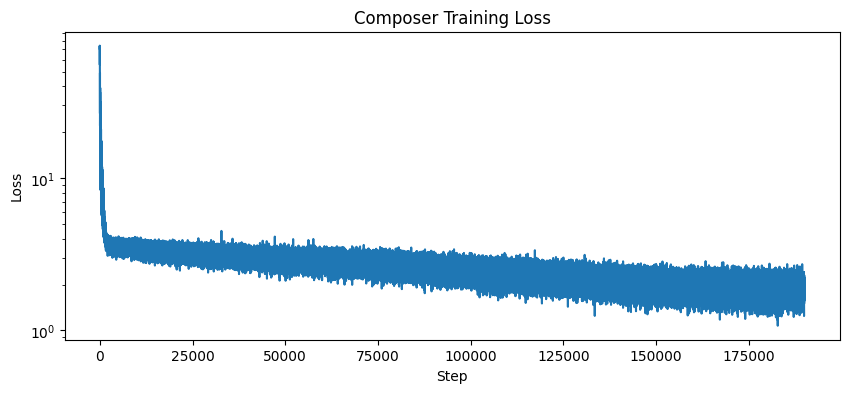

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Composer Training Evals

In [14]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

Using cpu
Loaded 10791 v0.7 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 128])
Encoded chemical sequences: torch.Size([188, 128])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 128])
seq_to_target_retrieval: dna_mrr=0.0282
cross_modality_target_consistency: Within=0.8271, Between=0.7924, Ratio=1.04x
seq_target_gap_analysis: dna_gap=0.78
paired_alignment_quality: dna_sim=0.8980
mode_sensitivity: Classification_acc=0.9905 (6.9x chance)
mode_semantic_consistency: semantic_gap=-0.0496, cross_mode_mrr=0.0808
fusion_quality: Fused_var=0.2473, Seq_var=0.2164, Target_var=0.0123
missing_data_robustness: Fused_MRR=0.1869, Seq_only=0.0179, Target_only=0.9950
found 135 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|████████████| 500/500 [00:02<00:00, 190.19it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0868, target_only=0.0978, fused=0.1382
action_vector_pathways DNA: ratio=1.00055391914277
Saved report to /Users/djemec/data/jepa/v0_7/eval_results/composer_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.028222949845609552,
    'median_rank': 451.0,
    'mean_rank': 1104.6,
    'n_queries': 10630,
    'n_targets': 9975,
    'recall_at_k': {'1': 0.008560677328316087,
     '5': 0.03461900282220132,
     '10': 0.05983066792097836,
     '20': 0.0980244590780809,
     '50': 0.1737535277516463}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 921,
   'n_within_pairs': 1408,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.8271397948265076,
   'between_target_sim': 0.7923831053197384,
   'consistency_ratio': 1.043863491376112}},
 'seq_target_gap_analysis': {'target_variance': 1.7399342060089111,
  'n_targets': 9975,
  'dna': {'seq_variance': 28.482572555541992,
   'centroid_distance': 2.0733566284179688,
   'mean_within_seq': 7.410699249096985,
   'mean_seq_to_target': 5.79201078414917,
   'gap_ratio': 0.7815741253910612,
   'n_sequences': 11643}},
 'paired_a

In [15]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): CellStateEncoder(
    (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
    (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
    (fourier_projection): GaussianFourierProjection()
    (film_generator): Sequential(
      (0): Linear(in_features=8, out_features=8, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=8, out_features=16, bias=True)
    )
    (total_count_proj): Linear(in_features=1, out_features=8, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x CellStateBlock(
        (ln_1): RMSNorm()
        (attn): BioLinearAttention(
          (q_proj): Linear(in_features=8, out_features=8, bias=True)
          (k_proj): Linear(in_features=8, out_features=8, bias=True)
          (v_proj): Linear(in_features=8, out_features=8, bias=True)
          (c_proj): Linear(in_features=8, out_features=8, bias=True)
          (gate): Linear(in_features=8, out_features=8, bias=True)
        )
        (ln_2):

## Stage 3: AC Training

In [16]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 66 shards for split val
AC training: 3857920 samples, 120560 steps/epoch, 1000 total steps
Mask annealing: starts at step 800 (0.766 -> 0.000)
Beta-NLL: target=0.20, anneal steps=300
Step 0 | val loss: 41.7617
Step 0 | Loss: 43.17724 | LR: 4.10e-06 | Beta: 0.000
Step 100 | Loss: 35.85989 | LR: 9.93e-05 | Beta: 0.067
Step 200 | Loss: 32.69814 | LR: 9.38e-05 | Beta: 0.133
Step 300 | Loss: 32.74443 | LR: 8.36e-05 | Beta: 0.200
Step 400 | Loss: 31.19324 | LR: 6.98e-05 | Beta: 0.200
Step 500 | val loss: 30.9888
Step 500 | Loss: 32.51068 | LR: 5.38e-05 | Beta: 0.200
Step 600 | Loss: 32.04894 | LR: 3.74e-05 | Beta: 0.200
Step 700 | Loss: 32.54774 | LR: 2.24e-05 | Beta: 0.200
Step 800 | Loss: 37.50465 | LR: 1.03e-05 | Beta: 0.200
Step 

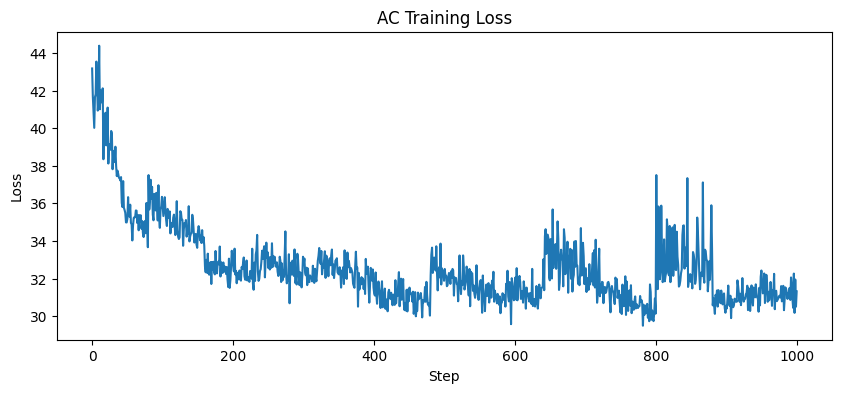

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [18]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [6]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device,
    total_samples=11044)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 66 shards for split val
Decoder training: 101682 samples, 3177 steps/epoch, 3177 total steps
Decoder Step 0 | val loss: 4.0783
Decoder Step 0 | Loss: 3.76519
Decoder Step 100 | Loss: 3.92499
Decoder Step 200 | Loss: 2.14289
Decoder Step 300 | Loss: 0.92299
Decoder Step 400 | Loss: 0.56626
Decoder Step 500 | val loss: 0.5549
Decoder Step 500 | Loss: 0.52953
Decoder Step 600 | Loss: 0.66101
Decoder Step 700 | Loss: 0.38166
Decoder Step 800 | Loss: 0.24035
Decoder Step 900 | Loss: 0.33765
Decoder Step 1000 | val loss: 0.3211
Decoder Step 1000 | Loss: 0.31569
Decoder Step 1100 | Loss: 0.30775
Decoder Step 1200 | Loss: 0.19072
Decoder Step 1300 | Loss: 0.30063
Decoder Step 1400 | Loss: 0.18734
Decoder Step 1500 | val loss: 0.2993
De

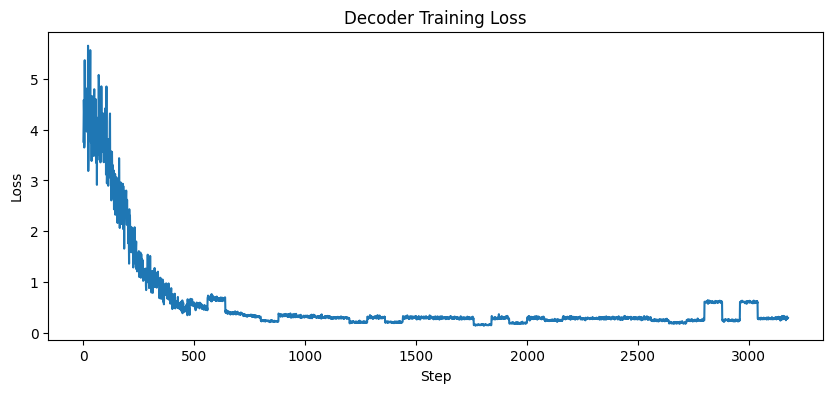

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [8]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

Using cpu
found 135 shards for split test


Running test inference:   0%|                                            | 0/10800 [00:00<?, ?it/s]

Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Loaded target bank: torch.Size([9975, 320])


Running test inference:   1%|▏                                | 81/10800 [01:01<7:06:07,  2.39s/it]/Users/djemec/code/biojepa_unified/biojepa/evals/evals.py:626: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference: 100%|██████████████████████████████| 10800/10800 [2:03:21<00:00,  1.46it/s]


Aggregated 1416 single-pert, 13 multi-pert perturbations, 345600 samples, 135 shards
  adamson: 11 perturbations, 4288 samples
  k562e_raw: 286 perturbations, 46506 samples
  k562gw: 1053 perturbations, 189095 samples
  norman: 10 perturbations, 9472 samples
  rep1e: 287 perturbations, 22838 samples
  sciplex: 54 perturbations, 73401 samples
Cached test inference to /Users/djemec/data/jepa/v0_7/test_inference_cache (135 shards)
expression_prediction: Pearson=0.9861, R2=0.9692, Centroid_acc=0.0008
gene_level_analysis: Dir_acc=0.9845, Top50_acc=0.6707


perturbation_retrieval (dna): 100%|█████████████████████████████████| 5/5 [18:59<00:00, 227.89s/it]


perturbation_retrieval (dna): MRR=0.0009


perturbation_retrieval (chemical): 100%|█████████████████████████████| 5/5 [00:18<00:00,  3.70s/it]


perturbation_retrieval (chemical): MRR=0.0113
Loaded dataset gene masks: ['k562e_raw', 'rep1e', 'k562gw', 'adamson', 'norman', 'sciplex']
uncertainty_calibration: ECE=0.1978, Monotonicity=55.56%
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
moa_matching expression: Within=0.9572, Between=0.9542, Gap=0.0031, Ratio=1.0032x
moa_matching latent: Within=0.8986, Between=0.8991, Gap=-0.0005, Ratio=0.9994x
Loaded Norman combo mapping: 132 combos
Loaded Norman single-gene deltas: 105 genes
Loaded Norman GI subtypes: 88 combos
Loaded dataset splits: ['k562e_raw', 'rep1e', 'k562gw', 'adamson', 'norman', 'sciplex']
combination_perturbation: 13 combo perts, 4283 samples, 13 additive baseline, 5 GI-labeled, 13 generalization-classified
dose_response: monotonicity=46.30%, real_mono=48.77%, spearman=-0.0043, curve_sim=-0.18769937245380078
Saved report to /Users/djemec/data/jepa/v0_7/eval_results/ac_eval_report.json


{'expression_prediction': {'config': {'test_perturbations': 1416,
   'genes': 10000,
   'test_samples': 345600},
  'sample_level': {'mse': 0.34757593751227467,
   'pearson_r_top20': 0.24086953741455444},
  'perturbation_level': {'r2_all_genes': {'mean': 0.9691765220404345,
    'median': 0.9832366406917572},
   'r2_top50_degs': {'mean': 0.694467310809483, 'median': 0.8301551342010498},
   'mse': {'mean': 0.007441823836416006, 'median': 0.00359940598718822},
   'pearson_all_genes': {'mean': 0.9861164747153298,
    'median': 0.9925349056720734},
   'pearson_delta_all_genes': {'mean': 0.012337128032716768,
    'median': 0.013062434736639261},
   'pearson_top50_degs': {'mean': 0.023092161812740614,
    'median': 0.01741049252450466}},
  'centroid_accuracy': {'accuracy': 0.0007535795026375283, 'n_groups': 1327},
  'vs_baseline': {'beat_rate': 0.0, 'n_evaluated': 1416},
  'severity': {'pearson_r': 0.3336423635482788,
   'spearman_r': 0.2224207198137654},
  'error_by_magnitude': {'0-0.25': {'m

In [9]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [10]:
print('=== Training Complete ===')
print(f'Encoder training final loss: {pt_results["final_loss"]:.5f}')
print(f'Composer training final loss: {align_results["final_loss"]:.5f}')
print(f'AC training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')

=== Training Complete ===


NameError: name 'pt_results' is not defined